# Management Disaster Response Two Stage

rough plan
1) Introduction to the Problem
2) Problem Formulation
3) solving via dyerministic, single cut, multi cut, lagrangian convergence graphs and other plots

## 1. Problem Introduction

The pre positioning of emergency supplies is a vital  strategy for responding to natural disasters, such as hurricanes, earthquakes, or tornados. The primary objective of this model is to determine the optimal locations, size capacities, and quantities of various emergency supplies such as water, food, and medical kits to stock prior to an event. 

The main difficulty in creating this pre-positioning plan is the inherent uncertainty regarding whether a disaster will occur, its specific location, and its magnitude. To address this, the problem is formulated as a two stage stochastic program. 

* First stage decisions: Decisions made prior to any disaster realization, including where to open storage facilities, the size of those facilities, and the amount of each commodity to stock.
* Second stage decisions: Conditional decisions made after a disaster scenario is realized, which involve distributing the surviving supplies across a potentially damaged transportation network to meet local demands.

## 2. Mathematical Formulation

### Sets and Indices
* $K$: Set of commodities, indexed by $k \in K$.
* $I$: Set of facility locations, indexed by $i \in I$.
* $S$: Set of discrete disaster scenarios, indexed by $s \in S$.
* $L$: Set of facility size categories, indexed by $l \in L$.
* $N$: Full set of nodes in the network.
* $A$: Set of transportation arcs $(i,j)$ in the network.

### Variables
first Stage Variables:
* $y_{il} \in \{0, 1\}$: 1 if a supply facility of size $l$ is located at node $i$, 0 otherwise.
* $r_i^k \ge 0$: Amount of commodity $k$ pre positioned at location $i$.

Second Stage Variables:
* $x_{ij}^{ks} \ge 0$: Amount of commodity $k$ shipped across link $(i,j)$ in scenario $s$.
* $z_i^{ks} \ge 0$: Amount of commodity $k$ unused at location $i$ in scenario $s$.
* $w_i^{ks} \ge 0$: Shortage (unmet demand) of commodity $k$ at location $i$ in scenario $s$.

### Objective Function
Minimize expected costs:
$$ \min \sum_{i \in I} \sum_{l \in L} F_{il} y_{il} + \sum_{k \in K} \sum_{i \in I} q^k r_i^k + \sum_{s \in S} P_s \left[ \sum_{(i,j) \in A} \sum_{k \in K} c_{ij}^{ks} x_{ij}^{ks} + \sum_{i \in I} \sum_{k \in K} (h^k z_i^{ks} + p^k w_i^{ks}) \right] $$

Subject to:
$$ \sum_{j \neq i \in N} x_{ji}^{ks} + \rho_i^{ks} r_i^k - z_i^{ks} = \sum_{j \neq i \in N} x_{ij}^{ks} + v_i^{ks} - w_i^{ks} \quad \forall i \in N, k \in K, s \in S $$ 

$$ \sum_{k \in K} u^k x_{ij}^{ks} \le U_{ij}^s \quad \forall (i,j) \in A, s \in S $$ 

$$ \sum_{k \in K} b^k r_i^k \le \sum_{l \in L} M_l y_{il} \quad \forall i \in I $$ 

$$ \sum_{l \in L} y_{il} \le 1 \quad \forall i \in I $$

# Getting The Data

There are 5 .csv files
* Links
* Commodities
* facility sizes
* Hurriccanes
* Sceenarios

What is directly copied from the Paper:
* Commodities
* Facility Sizes
* Hurricanes
* Scenarios

What is estimated:
* nodes
* links 
  




# Modelling Assumptions

* 1) Facility Destruction rule, major hurricans are of greater then classification 3 reslting in p to be 0. for minor huriccans p is 0.5
* 2) For Combined scenarios , we can take the unon of landfall nodes and unusable links from both storms and sum


### The Feedback Loop
If we tried to solve everything all at once for every possible hurricane combination, the math problem would be too massive for the computer. So, we use **Benders Decomposition**:

1. The Master Problem takes a guess and buys some inventory.
2. We pass that inventory amount to the Subproblems (one for each hurricane scenario).
3. The Subproblems do their best to distribute the goods. They calculate the total cost (transport + penalties). 
4. More importantly, the Subproblems calculate Duals. This is basically the workers telling the manager: "For every extra unit of water you give us at Node 5, we could have saved $50 in penalties!"
6. We use those duals to create a cut. We add this cut to the Master Problem so it knows better for next time.
8. We repeat this loop until the Manager's cost guess matches the Workers' actual costs.

In [16]:
from data_loader import load_problem_data
from benders import benders, gap_trajectory
from deterministic import solve_deterministic
from report import comparison_table, facility_plan_df

In [17]:
data = load_problem_data(".")
print(f"Loaded case study: {len(data.nodes)} nodes, {len(data.commodities)} commodities, "
      f"{len(data.facility_sizes)} facility sizes, {len(data.scenarios)} scenarios")

Loaded case study: 30 nodes, 3 commodities, 3 facility sizes, 51 scenarios


In [22]:
print("Running [1/3] Benders singl cut:")
single = benders(
    data, data.nodes, cut_mode="single", tol=0.02, max_iter=20, verbose=False,
)
print(f"  done in {single['total_time']:.1f}s | "
      f"{single['iteration'][-1]} iterations | "
      f"gap {single['final_gap']*100:.2f}% | "
      f"objective ${single['best_upper_bound'][-1]:,.0f}")

print("Running [2/3] Benders multi cut:")
multi = benders(
    data, data.nodes, cut_mode="multi", tol=0.02, max_iter=20, verbose=False,
)
print(f"  done in {multi['total_time']:.1f}s | "
      f"{multi['iteration'][-1]} iterations | "
      f"gap {multi['final_gap']*100:.2f}% | "
      f"objective ${multi['best_upper_bound'][-1]:,.0f}")

print("Running [3/3] Deterministic:")
det = solve_deterministic(data, data.nodes, time_limit=300, gap_tol=None, msg=False)
print(f"  done in {det['time']:.1f}s | status {det['status']} | "
      f"objective ${det['objective']:,.0f}")

Running [1/3] Benders singl cut:
  done in 16.4s | 20 iterations | gap 7.47% | objective $84,887,746
Running [2/3] Benders multi cut:
  done in 17.8s | 20 iterations | gap 5.47% | objective $84,758,998
Running [3/3] Deterministic:
  done in 92.5s | status Optimal | objective $84,566,285


In [23]:
comparison_table(single, multi, det)

,method,iterations,time_s,gap_pct,objective
0,Benders single-cut,20,16.4,7.47,84887746
1,Benders multi-cut,20,17.8,5.47,84758998
2,Deterministic (extensive form),1,92.5,0.00,84566285


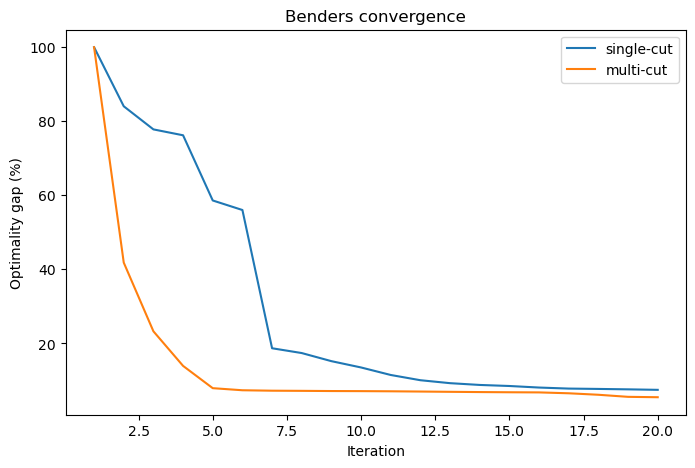

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(single["iteration"], gap_trajectory(single), label="single-cut")
ax.plot(multi["iteration"], gap_trajectory(multi), label="multi-cut")
ax.set_xlabel("Iteration")
ax.set_ylabel("Optimality gap (%)")
ax.set_title("Benders convergence")
ax.legend()
plt.show()


In [21]:
facility_plan_df(data, data.nodes, multi["best_solution"])

,node,facility_size,Water,Food,Medical kits
0,"Nashville, TN",Large,1931.2,3901.0,28454.4
1,"Tallahassee, FL",Large,5394.2,0.0,0.0


References: 

https://www.sciencedirect.com/science/article/pii/S0191261509001118

Introduction to Stochastic Programming (Springer Series in Operations Research,  John R. Birge



